# NYC Yellow Taxi — Tidy Dataset Homework

## THAT-A-SCIENCE
+ Andres Alencaster Huitron - 3403171
+ Isaac Palatto Sanchez - 3407062
+ Juan Pablo Mayne Carranco - 3403170
+ Romain Leclerc - 3402982
+ Samuel Lelouch - 3402913


**Goal:** Identify data quality issues and produce a single, tidy dataset.

## 0. Setup

In [16]:
# Loading the necessary packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# So we can actually see all of the columns 
pd.set_option('display.max_columns', None)

# The paths
RAW_PATH  = 'taxi_tidy_dirty.csv'
OUT_PATH  = 'tidy_dataset_THAT-A-SCIENCE.csv'

## 1. Load the raw data

Firstly, we will load the data. Afterwars we will print the first rows to understand what are we working with.

In [18]:
df_raw = pd.read_csv(RAW_PATH)
print(f'Shape: {df_raw.shape}')
print()

nb_rows = df_raw.shape[0]
print(df_raw.head())

# Define the df which we will work on
df = df_raw.copy()

Shape: (491301, 19)

   pickup_hour  pickup_month  pickup_week  pickup_doy  pickup_wday  \
0         10.0             5           21         141            6   
1         21.0             5           21         144            2   
2         17.0             5           21         143            1   
3         13.0             5           19         128            7   
4         11.0             5           21         143            1   

   length_time  pickup_BoroCode pickup_NTACode  dropoff_BoroCode  \
0         1720              1.0           MN31                 1   
1          950              1.0           MN25                 1   
2          957              1.0           MN25                 1   
3          174              1.0           MN19                 1   
4          521              1.0           MN99                 1   

  dropoff_NTACode  pickup_longitude  pickup_latitude  dropoff_longitude  \
0            MN14        -73.957092        40.770435         -73.984016   

## 2. Looking for the issues and resloving them
### 2.1) Exploring the data

In [24]:
# Quick sanity-check, describe the information and see any strange behaviour
df.describe()

,pickup_hour,pickup_month,pickup_week,pickup_doy,pickup_wday,length_time,pickup_BoroCode,dropoff_BoroCode,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,vendor_id,passenger_count,trip_distance,fare_amount
count,491165.000000,491301.0,491301.000000,491301.000000,491301.000000,491301.000000,491165.000000,491301.000000,491301.000000,491301.000000,491301.000000,491301.000000,491301.000000,491301.000000,4.913010e+05,491301.000000
mean,13.613065,5.0,19.900004,136.342250,3.916402,984.616152,1.210396,1.274823,-73.959785,40.742737,-73.973544,40.751074,1.526117,1.641301,2.813154e+01,13.449470
std,6.461629,0.0,1.278179,8.667125,1.979215,2694.958874,0.740929,0.790916,1.023816,0.564289,0.033460,0.031820,0.499318,1.293644,1.712494e+04,10.360289
min,0.000000,5.0,18.000000,122.000000,1.000000,-84138.000000,1.000000,1.000000,-74.104080,0.000000,-74.242378,40.502365,1.000000,0.000000,-2.000000e+01,-53.000000
25%,9.000000,5.0,19.000000,129.000000,2.000000,434.000000,1.000000,1.000000,-73.992378,40.736298,-73.991577,40.734570,1.000000,1.000000,1.100000e+00,7.000000
50%,14.000000,5.0,20.000000,136.000000,4.000000,716.000000,1.000000,1.000000,-73.981934,40.752991,-73.979866,40.753632,2.000000,1.000000,1.830000e+00,10.000000
75%,19.000000,5.0,21.000000,144.000000,6.000000,1157.000000,1.000000,1.000000,-73.967636,40.768681,-73.963333,40.770138,2.000000,2.000000,3.400000e+00,15.500000
max,23.000000,5.0,22.000000,152.000000,7.000000,86393.000000,5.000000,5.000000,0.000000,40.901421,-73.701439,40.911293,2.000000,8.000000,1.200000e+07,500.000000


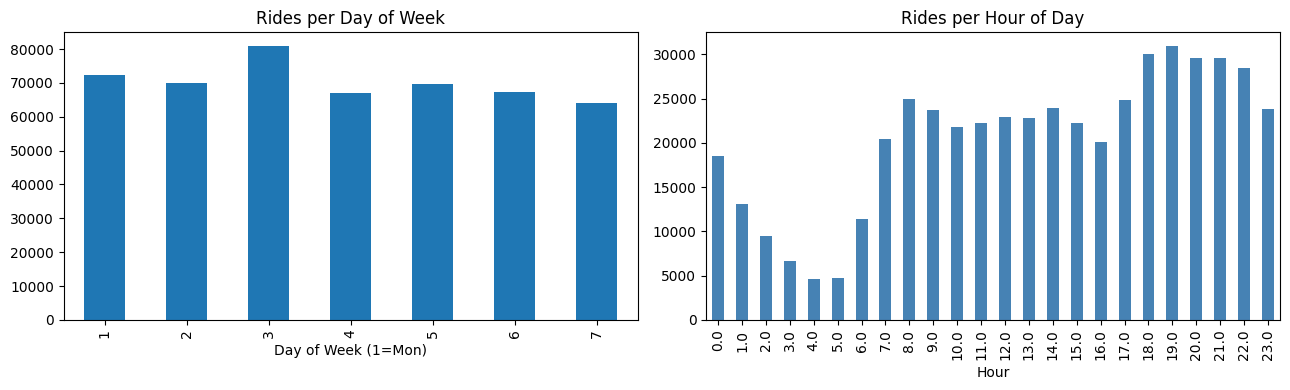

In [212]:
# Quick sanity-check plot: rides per day of week in tidy dataset
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df['pickup_wday'].value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Rides per Day of Week')
axes[0].set_xlabel('Day of Week (1=Mon)')

df['pickup_hour'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Rides per Hour of Day')
axes[1].set_xlabel('Hour')

plt.tight_layout()
plt.show()

### 2.1 Non-Standard Temporal Encoding (Index Shift & Modulo Anomaly)

The year of 2015 is a normal year and february has only 28 days.
We can thus deduce :
January : 31 days
February : 28 days
March : 31 days
April : 30 days
31 + 28 + 31 + 30 = 120.

The 1st of may is the `121th day of the year`. May has 31 days so the 31st of may is the `151th day of the year` 

In [213]:
np.sort(df["pickup_doy"].unique())

array([122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134,
       135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147,
       148, 149, 150, 151, 152])

We observe a systematic shift in the `pickup_doy` values, which range from 122 to 152, whereas the standard calendar non-leap year 2015 defines May from day 121 to 151.

In [214]:
df.head()

,pickup_hour,pickup_month,pickup_week,pickup_doy,pickup_wday,length_time,pickup_BoroCode,pickup_NTACode,dropoff_BoroCode,dropoff_NTACode,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,vendor_id,passenger_count,trip_distance,fare_amount,pair
0,10.0,5,21,141,6,1720,1.0,MN31,1,MN14,-73.957092,40.770435,-73.984016,40.770363,2,1,1.90,18.0,MN31-MN14
1,21.0,5,21,144,2,950,1.0,MN25,1,MN31,-74.014961,40.713902,-73.951485,40.769936,2,1,7.68,23.5,MN25-MN31
2,17.0,5,21,143,1,957,1.0,MN25,1,MN17,-74.016182,40.715004,-73.994980,40.750099,1,1,3.30,14.0,MN25-MN17
3,13.0,5,19,128,7,174,1.0,MN19,1,MN31,-73.968384,40.759090,-73.961853,40.759750,2,2,0.49,4.0,MN19-MN31
4,11.0,5,21,143,1,521,1.0,MN99,1,MN12,-73.962578,40.778759,-73.979012,40.785248,2,1,1.37,8.0,MN99-MN12


Here we can make some calculations :
For the row `0`, `pickup_doy` shows `141`, and `pickup_wday` shows `6`. <br>
Using the shifted calendar, the 141th day of the year is `141-121 = 20` is the 20th of May :  `122-121=1`  is the first of May. <br>
Now by checking a calendar, the 20th of May of 2015 is a Wednesday. This would mean that the weekday `6` means Wednesday. <br>
We can check the others but the 143th doy is the 22snd of May and is the friday. <br>
This means the that convention for the pickup_wday is : `{1: Friday, 2: Saturday, 3: Sunday, 4: Monday, 5: Tuesday, 6: Wednesday, 7: Thursday}`. This is absurd and will justify why we will remove those two columns, indeed, in the next part, we will create a full datetime column with everything, and those values can be directly from this new column.

### 2.2 Scattered Temporal Components

We have to many columns representing values on the date of the trip. We want to combine them in a simple cell, but to do that, we won't use a normal datatype like `string` because we would loose all the possible operations possibles on the values. We will use the datatype : `datetime64` that is specifically made for this.

In [215]:
df['pickup_datetime'] = pd.to_datetime(pd.DataFrame({
    'year': 2015, 
    'month': df['pickup_month'],
    'day': df['pickup_doy'] - 121,
    'hour': df['pickup_hour']
}))

df.insert(0, 'pickup_datetime', df.pop('pickup_datetime')) # We insert it a the first column

By consolidating the temporal components into a single `pickup_datetime` column, we transition from a fragmented representation to a unified, continuous time domain. This allows us to remove the following columns while having an easy acess with the original features:

| Feature to Remove | Pandas Recovery Accessor (Vectorized) 
| :--- | :--- |
| `pickup_hour` | `df['pickup_datetime'].dt.hour` |
| `pickup_month` | `df['pickup_datetime'].dt.month` | 
| `pickup_doy` | `df['pickup_datetime'].dt.dayofyear` | 
| `pickup_wday` | `df['pickup_datetime'].dt.dayofweek` (in this case, 0 -> Monday and 6 -> Sunday)|
| `pickup_week` | `df['pickup_datetime'].dt.isocalendar().week` |

We can then remove these columns :

In [216]:
df = df.drop(columns=["pickup_hour", "pickup_month", "pickup_doy", "pickup_wday", "pickup_week"])

### 2.3 Redundant Variables

In [217]:
df = df.drop(columns=['pair'])

### 2.4 Innapropriate data types

Let's look at the types of the columns :

In [218]:
df.dtypes

pickup_datetime      datetime64[ns]
length_time                   int64
pickup_BoroCode             float64
pickup_NTACode               object
dropoff_BoroCode              int64
dropoff_NTACode              object
pickup_longitude            float64
pickup_latitude             float64
dropoff_longitude           float64
dropoff_latitude            float64
vendor_id                     int64
passenger_count               int64
trip_distance               float64
fare_amount                 float64
dtype: object

We see that some columns do not have the right type : 
`pickup_BoroCode` should be an `int64` and not a `float64`, same thing for `dropoff_BoroCode`

We want to convert the types of some columns to int64, but first we need to check that all the values are indeed ints.

We can now see that both `pickup_hour` and `pickup_BoroCode` contains the value `nan` that connot be converted to int64, to work around this, we will convert them both to `Int64` that allows `nan` as a value.

In [219]:
df["pickup_BoroCode"] = df["pickup_BoroCode"].astype('Int64')

df['dropoff_BoroCode'] = df['dropoff_BoroCode'].astype('int64')

### 2.5 Inconsistent naming conventions

In [220]:
rename_dict = {
    'pickup_BoroCode': 'pickup_boro_code',
    'pickup_NTACode': 'pickup_nta_code',
    'dropoff_BoroCode': 'dropoff_boro_code',
    'dropoff_NTACode': 'dropoff_nta_code',
}

df = df.rename(columns=rename_dict)
df

,pickup_datetime,length_time,pickup_boro_code,pickup_nta_code,dropoff_boro_code,dropoff_nta_code,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,vendor_id,passenger_count,trip_distance,fare_amount
0,2015-05-20 10:00:00,1720,1,MN31,1,MN14,-73.957092,40.770435,-73.984016,40.770363,2,1,1.90,18.0
1,2015-05-23 21:00:00,950,1,MN25,1,MN31,-74.014961,40.713902,-73.951485,40.769936,2,1,7.68,23.5
2,2015-05-22 17:00:00,957,1,MN25,1,MN17,-74.016182,40.715004,-73.994980,40.750099,1,1,3.30,14.0
3,2015-05-07 13:00:00,174,1,MN19,1,MN31,-73.968384,40.759090,-73.961853,40.759750,2,2,0.49,4.0
4,2015-05-22 11:00:00,521,1,MN99,1,MN12,-73.962578,40.778759,-73.979012,40.785248,2,1,1.37,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
491296,2015-05-25 08:00:00,1024,1,MN12,1,MN17,-73.978249,40.788395,-73.977234,40.759800,1,1,2.60,13.0
491297,2015-05-19 22:00:00,659,1,MN17,1,MN23,-73.986092,40.752178,-73.993958,40.725159,2,1,2.38,10.0
491298,2015-05-30 04:00:00,1170,1,MN19,4,QN98,-73.969643,40.757233,-73.871017,40.773972,1,2,9.70,28.0
491299,2015-05-22 13:00:00,321,1,MN17,1,MN17,-73.991470,40.749569,-73.986732,40.746101,2,1,0.45,5.0


## Recap of all issues found : 

| Data Issue / Observation | Tidy Data Principle / Homework Guideline | Proposed Solution (Pandas Implementation) |
| :--- | :--- | :--- |
| **Scattered Temporal Components**<br>Time information is fragmented across multiple columns (`pickup_hour`, `pickup_month`). Furthermore, `pickup_month` has zero variance (constant = 5). | **Observation Coherence & Parsimony**<br>A single temporal observation must be unified. Variables that are constant artificially inflate dimensionality without adding variance and must be removed. | **Variable Aggregation**<br>Create a single `pickup_datetime` column combining the necessary components, then drop the original fragmented columns. |
| **Non-Standard Temporal Encoding (Index Shift & Modulo Anomaly)**<br>The `pickup_doy` is shifted by +1 (May 1st is 122 instead of 121). Also, `pickup_wday` follows an arbitrary, non-ISO cyclic encoding where Friday = 1 | **Reference Frame Consistency**<br>Variables must follow standard international reference frames (e.g., ISO 8601 where Monday = 0 or 1). Arbitrary bases introduce structural bias and corrupt downstream mathematical modeling. | **Re-projection & Elimination**<br>Drop both `pickup_wday` and `pickup_doy`. The unified `datetime64` object natively standardizes the temporal space to the ISO format, resolving the anomaly. |
| **Redundant Variables**<br>The `pair` column is merely a string concatenation of two existing independent geographical variables (e.g., `MN13-MN17`). | **Atomicity**<br>A dataset should not contain trivial linear combinations or redundant strings of already existing independent variables. | **Drop Column**<br>Delete the column "pair" by applying the `.drop(columns=['pair'])` method to eliminate this redundant dimensionality. |
| **Inappropriate Data Types**<br>Categorical variables or discrete integer identifiers (like `pickup_BoroCode` or `vendor_id`) are encoded as floating-point numbers (`float64`). | **Type Integrity**<br>Data types in memory must reflect their true statistical nature (discrete vs. continuous) to ensure reliable operations and memory optimization. | **Recast Variables**<br>Convert these columns to appropriate types using the pandas `Int64` extension type to preserve integers while handling `NaN` values. |
| **Inconsistent Naming Conventions**<br>Column headers mix different typographical conventions (partial *CamelCase* like `pickup_BoroCode` alongside `snake_case`). | **Standardization (Isomorphic Mapping)**<br>Uniform identifiers are a fundamental development standard for robust and readable matrix manipulations. | **Rename Columns**<br>Standardize all column headers to a uniform convention (e.g., strictly `snake_case` like `pickup_boro_code`) using the `.rename()` method. |

## 4. Exploratory Data Analysis: Audit of the Vector Space

Since the constraints of the *Tidying* process forbid any imputation or modification of the signal (pre-processing), this section aims to rigorously demonstrate the existence of topological and physical anomalies in the dataset using descriptive statistics.

### 4.1 Univariate Analysis: Moments and Heavy Tails
In this step, we will analyze the distribution of isolated variables. We will compute the statistical moments and project the density of probabilities for key continuous variables such as `trip_distance` and `fare_amount`. The objective is to identify heavy-tailed distributions and isolate mathematical outliers (e.g., extreme values that deviate significantly from the expected variance).

### 4.2 Proof of Geometric and Physical Inconsistencies
A valid taxi ride must respect basic physical constraints. We will formally search for the existence of subsets containing geometric anomalies. 
For instance, let $x$ be a ride observation. We will attempt to isolate a subset $A$ such that the Euclidean displacement is null or negative, but the financial transaction implies a significant journey:
$A = \{x \in X \mid \text{trip\_distance}(x) \le 0 \land \text{fare\_amount}(x) > 0\}$
Identifying this subset will prove the presence of taximeter sensor failures or data entry errors.

### 4.3 Bivariate Analysis: Covariance Breakdown
We will study the matrix correlation between time and cost (`trip_duration` vs `fare_amount`). By projecting this bivariate relationship, we expect to observe a linear correlation for normal observations. However, this visualization will help us identify structural breaks, such as rides with negative fares or extremely long durations with minimal cost, highlighting logical inconsistencies in the billing process.

### 4.4 Assessing Spatio-Temporal Duplicates
Let $X$ be our sample of observations. We will identify the subset of identical vectors where $x_i = x_j$ for $i \neq j$. Since the dataset lacks a primary key (like a unique `trip_id`) to guarantee an injective mapping, we cannot formally deduce that identical vectors represent the exact same physical event $\omega$ rather than a highly probable spatio-temporal coincidence. Therefore, we will quantify these duplicates to assess the collision probability $\mathbb{P}(x_i = x_j \mid \omega_i \neq \omega_j)$, but we will retain them in the dataset to preserve the sample's variance.

## 5. Export Tidy Dataset

In [221]:
df.to_csv(OUT_PATH, index=False)
print(f'Tidy dataset saved → {OUT_PATH}')
print(f'Shape: {df.shape}')

Tidy dataset saved → tidy_dataset_THAT-A-SCIENCE.csv
Shape: (491301, 14)
